# Common Probability Distributions in Python
### CFA Level 1 Quantitative Methods | Applied to Real Market Scenarios

---

## The Scenario

You are a quantitative analyst at a global macro hedge fund.

You trade currencies.

Your head of risk walks in with five questions:

> 1. "What is the probability EUR/USD moves more than 1% in a single day?"
> 2. "If we run 20 independent FX trades, what is the probability
>     that at least 12 are profitable?"
> 3. "Our model assumes exchange rates are log-normally distributed.
>     Is that reasonable for USDTRY?"
> 4. "We have only 30 days of data on a new EM currency strategy.
>     Should we use normal or t-distribution for our confidence intervals?"
> 5. "Simulate 1,000 possible paths for our EUR/USD position over the next year."

Every question requires a different probability distribution.

This notebook builds each one from scratch,
applies it to real FX data from five currency pairs,
and answers every question on that sheet.

**Currency pairs:**
- **EURUSD** — major pair, liquid, near-normal returns
- **GBPUSD** — fat tails (Brexit, political risk)
- **USDJPY** — carry trade dynamics, regime shifts
- **USDTRY** — high inflation EM, extreme lognormal behavior
- **USDBRL** — emerging market with political risk episodes

**Data source:** Financial Modeling Prep (FMP) API

## Setup

We will use the following libraries:

- `requests` — to pull FX data from FMP API
- `pandas` — for data manipulation
- `numpy` — for mathematical operations
- `matplotlib` — for visualizations
- `scipy` — for distribution functions and statistical tests

In [3]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import warnings
from dotenv import load_dotenv
import os

load_dotenv()
warnings.filterwarnings('ignore')

FMP_KEY = os.getenv("FMP_KEY")

# Plot styling
plt.rcParams['figure.facecolor'] = '#0D1117'
plt.rcParams['axes.facecolor']   = '#161B22'
plt.rcParams['axes.edgecolor']   = '#30363D'
plt.rcParams['text.color']       = '#E6EDF3'
plt.rcParams['axes.labelcolor']  = '#E6EDF3'
plt.rcParams['xtick.color']      = '#8B949E'
plt.rcParams['ytick.color']      = '#8B949E'
plt.rcParams['grid.color']       = '#21262D'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.5

print("Libraries loaded successfully")
print("FMP Key loaded ✓" if FMP_KEY else "FMP Key missing ✗")

Libraries loaded successfully
FMP Key loaded ✓


## 1. Pulling Real FX Data

We pull 5 years of daily prices for five currency pairs.
Each pair tells a different story about return distributions.

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

| Pair | Characteristic |
|------|---------------|
| EURUSD | Liquid major — closest to normal |
| GBPUSD | Fat tails — Brexit volatility |
| USDJPY | Carry trade — regime shifts |
| USDTRY | High inflation EM — extreme lognormal |
| USDBRL | Political risk EM — jump behavior |

In [5]:
# =============================================================================
# CELL 5 — Pull FX Data from FMP
# =============================================================================

def get_fx(pair, api_key, from_date="2019-01-01", to_date="2024-01-01"):
    """Pull historical daily FX prices from FMP."""
    url = "https://financialmodelingprep.com/stable/historical-price-eod/full"
    params = {"symbol": pair, "from": from_date, "to": to_date, "apikey": api_key}
    response = requests.get(url, params=params)
    data = response.json()

    if isinstance(data, list) and len(data) > 0:
        df = pd.DataFrame(data)
    elif isinstance(data, dict) and "historical" in data:
        df = pd.DataFrame(data["historical"])
    else:
        print(f"  ✗ {pair} — no data returned")
        return None

    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    return df["close"]

# Define pairs
pairs = ["EURUSD", "GBPUSD", "USDJPY", "USDTRY", "USDBRL"]

# Pull all pairs
print("Pulling FX data from FMP...")
prices = pd.DataFrame()

for pair in pairs:
    px = get_fx(pair, FMP_KEY)
    if px is not None:
        prices[pair] = px
        print(f"  ✓ {pair} — {len(px)} days loaded")

# Compute log returns
returns = np.log(prices / prices.shift(1)).dropna()

print(f"\nData loaded successfully")
print(f"Period: {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Observations: {len(returns)} trading days")
print(f"\nQuick summary:")
print(returns.describe().round(6))

Pulling FX data from FMP...
  ✓ EURUSD — 1300 days loaded
  ✓ GBPUSD — 1305 days loaded
  ✓ USDJPY — 1305 days loaded
  ✓ USDTRY — 1303 days loaded
  ✓ USDBRL — 1305 days loaded

Data loaded successfully
Period: 2019-01-03 → 2024-01-01
Observations: 1295 trading days

Quick summary:
            EURUSD       GBPUSD       USDJPY       USDTRY       USDBRL
count  1295.000000  1295.000000  1295.000000  1295.000000  1295.000000
mean     -0.000020     0.000011     0.000207     0.001300     0.000234
std       0.004576     0.005945     0.005476     0.012171     0.009983
min      -0.020195    -0.036805    -0.038771    -0.224382    -0.037054
25%      -0.002653    -0.003303    -0.002295    -0.001575    -0.005843
50%      -0.000107    -0.000082     0.000255     0.000838     0.000264
75%       0.002653     0.003466     0.002915     0.004171     0.006021
max       0.021530     0.031169     0.031504     0.110001     0.046291


## 2. The Uniform Distribution

The simplest distribution — every outcome is equally likely.

$$f(x) = \frac{1}{b-a} \quad \text{for } a \leq x \leq b$$

In FX, the uniform distribution is rarely the right model.
But it is the right starting point — it is what you assume
when you have **no information** about which outcome is more likely.

**Practical use in macro trading:**
Before a central bank announcement, some analysts model
the rate decision as uniform across a range of outcomes
when they have no strong prior.

We use it here to answer a specific question:

> "If EUR/USD is equally likely to end anywhere in its
> historical daily range, what is the probability it
> moves more than 1% in either direction?"

We compare the uniform assumption to what actually happened.
This shows immediately why the uniform distribution
is not appropriate for financial returns.

In [6]:
# =============================================================================
# CELL 7 — Uniform Distribution Applied to EURUSD
# =============================================================================

r_eur = returns["EURUSD"].dropna().values
n     = len(r_eur)

# ── UNIFORM DISTRIBUTION PARAMETERS ──────────────────────────────────────────
a = r_eur.min()
b = r_eur.max()

# Uniform PDF and CDF
uniform_dist = stats.uniform(loc=a, scale=b - a)

# ── QUESTION: P(|return| > 1%) ────────────────────────────────────────────────
threshold = 0.01

# Uniform prediction
p_extreme_uniform = uniform_dist.cdf(-threshold) + (1 - uniform_dist.cdf(threshold))

# Empirical frequency
p_extreme_actual  = np.mean(np.abs(r_eur) > threshold)

# ── PRINT RESULTS ─────────────────────────────────────────────────────────────
print(f"{'='*60}")
print("UNIFORM DISTRIBUTION — EURUSD Daily Returns (2019–2023)")
print(f"{'='*60}")

print(f"\n  Range: [{a:.4%}, {b:.4%}]")
print(f"  Mean (uniform):  {(a+b)/2:.4%}")
print(f"  Std  (uniform):  {(b-a)/np.sqrt(12):.4%}")
print(f"  Mean (actual):   {r_eur.mean():.4%}")
print(f"  Std  (actual):   {r_eur.std():.4%}")

print(f"\n  QUESTION: P(|EURUSD return| > 1% in a single day)")
print(f"  {'─'*45}")
print(f"  Uniform prediction:   {p_extreme_uniform:.4%}")
print(f"  Actual frequency:     {p_extreme_actual:.4%}")
print(f"  Ratio:                {p_extreme_actual/p_extreme_uniform:.2f}x")

print(f"""
  INTERPRETATION
  The uniform distribution predicts a {p_extreme_uniform:.2%} probability
  of a move greater than 1% in either direction.

  In reality it happened {p_extreme_actual:.2%} of days
  — {p_extreme_actual/p_extreme_uniform:.1f}x {'more' if p_extreme_actual > p_extreme_uniform else 'less'} than the uniform predicts.

  The uniform distribution is wrong because FX returns
  are NOT equally distributed across the range.
  They cluster near zero — most days nothing happens.
  Extreme moves are rare but more common than uniform implies.

  CFA point: the uniform distribution is used when you have
  no information. In finance, you always have information.
  Always use a more appropriate distribution.
""")
print(f"{'='*60}")

UNIFORM DISTRIBUTION — EURUSD Daily Returns (2019–2023)

  Range: [-2.0195%, 2.1530%]
  Mean (uniform):  0.0667%
  Std  (uniform):  1.2045%
  Mean (actual):   -0.0020%
  Std  (actual):   0.4574%

  QUESTION: P(|EURUSD return| > 1% in a single day)
  ─────────────────────────────────────────────
  Uniform prediction:   52.0672%
  Actual frequency:     3.6293%
  Ratio:                0.07x

  INTERPRETATION
  The uniform distribution predicts a 52.07% probability
  of a move greater than 1% in either direction.

  In reality it happened 3.63% of days
  — 0.1x less than the uniform predicts.

  The uniform distribution is wrong because FX returns
  are NOT equally distributed across the range.
  They cluster near zero — most days nothing happens.
  Extreme moves are rare but more common than uniform implies.

  CFA point: the uniform distribution is used when you have
  no information. In finance, you always have information.
  Always use a more appropriate distribution.



## 3. The Binomial Distribution

The binomial distribution models the number of successes
in a fixed number of independent trials.

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

Where:
- $n$ = number of trials
- $k$ = number of successes
- $p$ = probability of success on each trial

**The trading question:**

> "Our FX desk runs 20 independent trades per month.
> Historically, each trade has a 55% win rate.
> What is the probability that at least 12 trades
> are profitable this month?"

This is a direct CFA exam question format.
We answer it using real win rate data from EURUSD
and then build the full probability distribution.

In [8]:
# =============================================================================
# CELL 9 — Binomial Distribution Applied to FX Trading
# =============================================================================
# We use the empirical win rate from EURUSD daily returns
# (days where return > 0) as our probability of success p.
# Then we model 20 independent trades per month.
# =============================================================================

# ── EMPIRICAL WIN RATE ────────────────────────────────────────────────────────
win_rates = {}
for pair in pairs:
    r = returns[pair].dropna()
    win_rates[pair] = (r > 0).mean()

print(f"{'='*55}")
print("EMPIRICAL WIN RATES — FX Pairs (2019–2023)")
print(f"{'='*55}")
for pair, wr in win_rates.items():
    print(f"  {pair:<10} {wr:.4%}")

# ── BINOMIAL SETUP ────────────────────────────────────────────────────────────
n = 20          # trades per month
p = win_rates["EURUSD"]  # empirical win rate

binom_dist = stats.binom(n, p)

# ── QUESTION: P(X >= 12) ─────────────────────────────────────────────────────
k_threshold = 12
p_at_least_12 = 1 - binom_dist.cdf(k_threshold - 1)

# ── FULL DISTRIBUTION ─────────────────────────────────────────────────────────
k_values = np.arange(0, n + 1)
pmf      = binom_dist.pmf(k_values)

print(f"\n{'='*55}")
print(f"BINOMIAL DISTRIBUTION — n={n} trades, p={p:.4%}")
print(f"{'='*55}")

print(f"\n  Expected wins:     {binom_dist.mean():.2f}")
print(f"  Std deviation:     {binom_dist.std():.2f}")
print(f"\n  P(X >= 12):        {p_at_least_12:.4%}")
print(f"  P(X >= 15):        {1 - binom_dist.cdf(14):.4%}")
print(f"  P(X < 10):         {binom_dist.cdf(9):.4%}")
print(f"  P(X = 10):         {binom_dist.pmf(10):.4%}")

print(f"\n  PROBABILITY MASS FUNCTION")
print(f"  {'k':>5} {'P(X=k)':>10} {'P(X<=k)':>10}")
print(f"  {'-'*28}")
for k in range(8, 16):
    marker = " ←" if k == k_threshold else ""
    print(f"  {k:>5} {binom_dist.pmf(k):>10.4%} {binom_dist.cdf(k):>10.4%}{marker}")

print(f"""
  INTERPRETATION
  With a {p:.2%} win rate on {n} trades:
  → Expected number of wins: {binom_dist.mean():.1f}
  → P(at least 12 wins) = {p_at_least_12:.2%}
  → P(fewer than 10 wins) = {binom_dist.cdf(9):.2%}

  CFA note: The binomial requires independent trials.
  In FX trading, this assumption is questionable —
  currency moves are correlated across days.
  Use the binomial as an approximation, not a law.
""")
print(f"{'='*55}")

EMPIRICAL WIN RATES — FX Pairs (2019–2023)
  EURUSD     48.9575%
  GBPUSD     49.6525%
  USDJPY     53.2819%
  USDTRY     58.8417%
  USDBRL     51.4286%

BINOMIAL DISTRIBUTION — n=20 trades, p=48.9575%

  Expected wins:     9.79
  Std deviation:     2.24

  P(X >= 12):        22.2626%
  P(X >= 15):        1.6484%
  P(X < 10):         44.8972%
  P(X = 10):         17.5433%

  PROBABILITY MASS FUNCTION
      k     P(X=k)    P(X<=k)
  ----------------------------
      8   13.0018%   28.2696%
      9   16.6276%   44.8972%
     10   17.5433%   62.4405%
     11   15.2970%   77.7374%
     12   11.0041%   88.7415% ←
     13    6.4951%   95.2367%
     14    3.1149%   98.3516%
     15    1.1951%   99.5467%

  INTERPRETATION
  With a 48.96% win rate on 20 trades:
  → Expected number of wins: 9.8
  → P(at least 12 wins) = 22.26%
  → P(fewer than 10 wins) = 44.90%

  CFA note: The binomial requires independent trials.
  In FX trading, this assumption is questionable —
  currency moves are correlat

## 4. The Normal Distribution

The normal distribution is the most important distribution in finance.
Not because financial returns are normal — they are not.
But because it is the benchmark everything else is measured against.

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

**The 68-95-99.7 rule:**
- 68% of observations fall within ±1σ
- 95% fall within ±2σ
- 99.7% fall within ±3σ

**The trading question:**

> "What is the probability EUR/USD moves more than 1%
> in a single day — assuming returns are normally distributed?
> How does this compare to reality?"

We answer this for all five currency pairs
and measure how badly the normal distribution
underestimates tail risk in each market.

In [9]:
# =============================================================================
# CELL 11 — Normal Distribution Applied to FX Returns
# =============================================================================

print(f"{'='*68}")
print("NORMAL DISTRIBUTION — FX Pairs (2019–2023)")
print(f"{'='*68}")

threshold = 0.01  # 1% move

print(f"\n  Question: P(|return| > 1%) for each currency pair")
print(f"\n  {'Pair':<10} {'Mean':>8} {'Std':>8} {'Normal P':>10} "
      f"{'Actual P':>10} {'Ratio':>8} {'Skew':>8} {'Kurt':>8}")
print(f"  {'-'*72}")

results = {}
for pair in pairs:
    r      = returns[pair].dropna().values
    mu     = r.mean()
    sigma  = r.std(ddof=1)
    nd     = stats.norm(mu, sigma)

    p_normal = nd.cdf(-threshold) + (1 - nd.cdf(threshold))
    p_actual = np.mean(np.abs(r) > threshold)
    ratio    = p_actual / p_normal if p_normal > 0 else np.inf
    skew     = stats.skew(r)
    kurt     = stats.kurtosis(r)

    results[pair] = {
        "mu": mu, "sigma": sigma,
        "p_normal": p_normal, "p_actual": p_actual,
        "ratio": ratio, "skew": skew, "kurt": kurt
    }

    print(f"  {pair:<10} {mu:>8.4%} {sigma:>8.4%} {p_normal:>10.4%} "
          f"{p_actual:>10.4%} {ratio:>8.2f}x {skew:>8.3f} {kurt:>8.3f}")

print(f"\n{'='*68}")

# ── 68-95-99.7 RULE VERIFICATION FOR EURUSD ──────────────────────────────────
r_eur  = returns["EURUSD"].dropna().values
mu_eur = r_eur.mean()
sd_eur = r_eur.std(ddof=1)

print(f"\n  68-95-99.7 RULE VERIFICATION — EURUSD")
print(f"  {'Range':<25} {'Normal Pred':>13} {'Actual':>10} {'Diff':>8}")
print(f"  {'-'*58}")

for n_sigma, expected in [(1, 0.6827), (2, 0.9545), (3, 0.9973)]:
    lo      = mu_eur - n_sigma * sd_eur
    hi      = mu_eur + n_sigma * sd_eur
    actual  = np.mean((r_eur >= lo) & (r_eur <= hi))
    print(f"  {'±'+str(n_sigma)+'σ ['+f'{lo:.3%}, {hi:.3%}]':<25} "
          f"{expected:>13.4%} {actual:>10.4%} {actual-expected:>+8.4%}")

print(f"""
  KEY INSIGHT
  The normal distribution underestimates tail risk for every pair.
  USDTRY is the most extreme — actual tail events are far more
  frequent than normal predicts.
  Skewness and excess kurtosis are the culprits — the same
  signatures we saw in equity returns in QM 03.
  No matter the asset class, financial returns are not normal.
""")
print(f"{'='*68}")

NORMAL DISTRIBUTION — FX Pairs (2019–2023)

  Question: P(|return| > 1%) for each currency pair

  Pair           Mean      Std   Normal P   Actual P    Ratio     Skew     Kurt
  ------------------------------------------------------------------------
  EURUSD     -0.0020%  0.4576%    2.8872%    3.6293%     1.26x    0.081    1.498
  GBPUSD      0.0011%  0.5945%    9.2547%    8.6486%     0.93x   -0.169    3.735
  USDJPY      0.0207%  0.5476%    6.8034%    6.4093%     0.94x   -0.447    7.299
  USDTRY      0.1300%  1.2171%   41.3950%   15.2896%     0.37x   -3.903  101.574
  USDBRL      0.0234%  0.9983%   31.6606%   28.3398%     0.90x    0.149    1.234


  68-95-99.7 RULE VERIFICATION — EURUSD
  Range                       Normal Pred     Actual     Diff
  ----------------------------------------------------------
  ±1σ [-0.460%, 0.456%]          68.2700%   73.0502% +4.7802%
  ±2σ [-0.917%, 0.913%]          95.4500%   94.8263% -0.6237%
  ±3σ [-1.375%, 1.371%]          99.7300%   98.8417% -

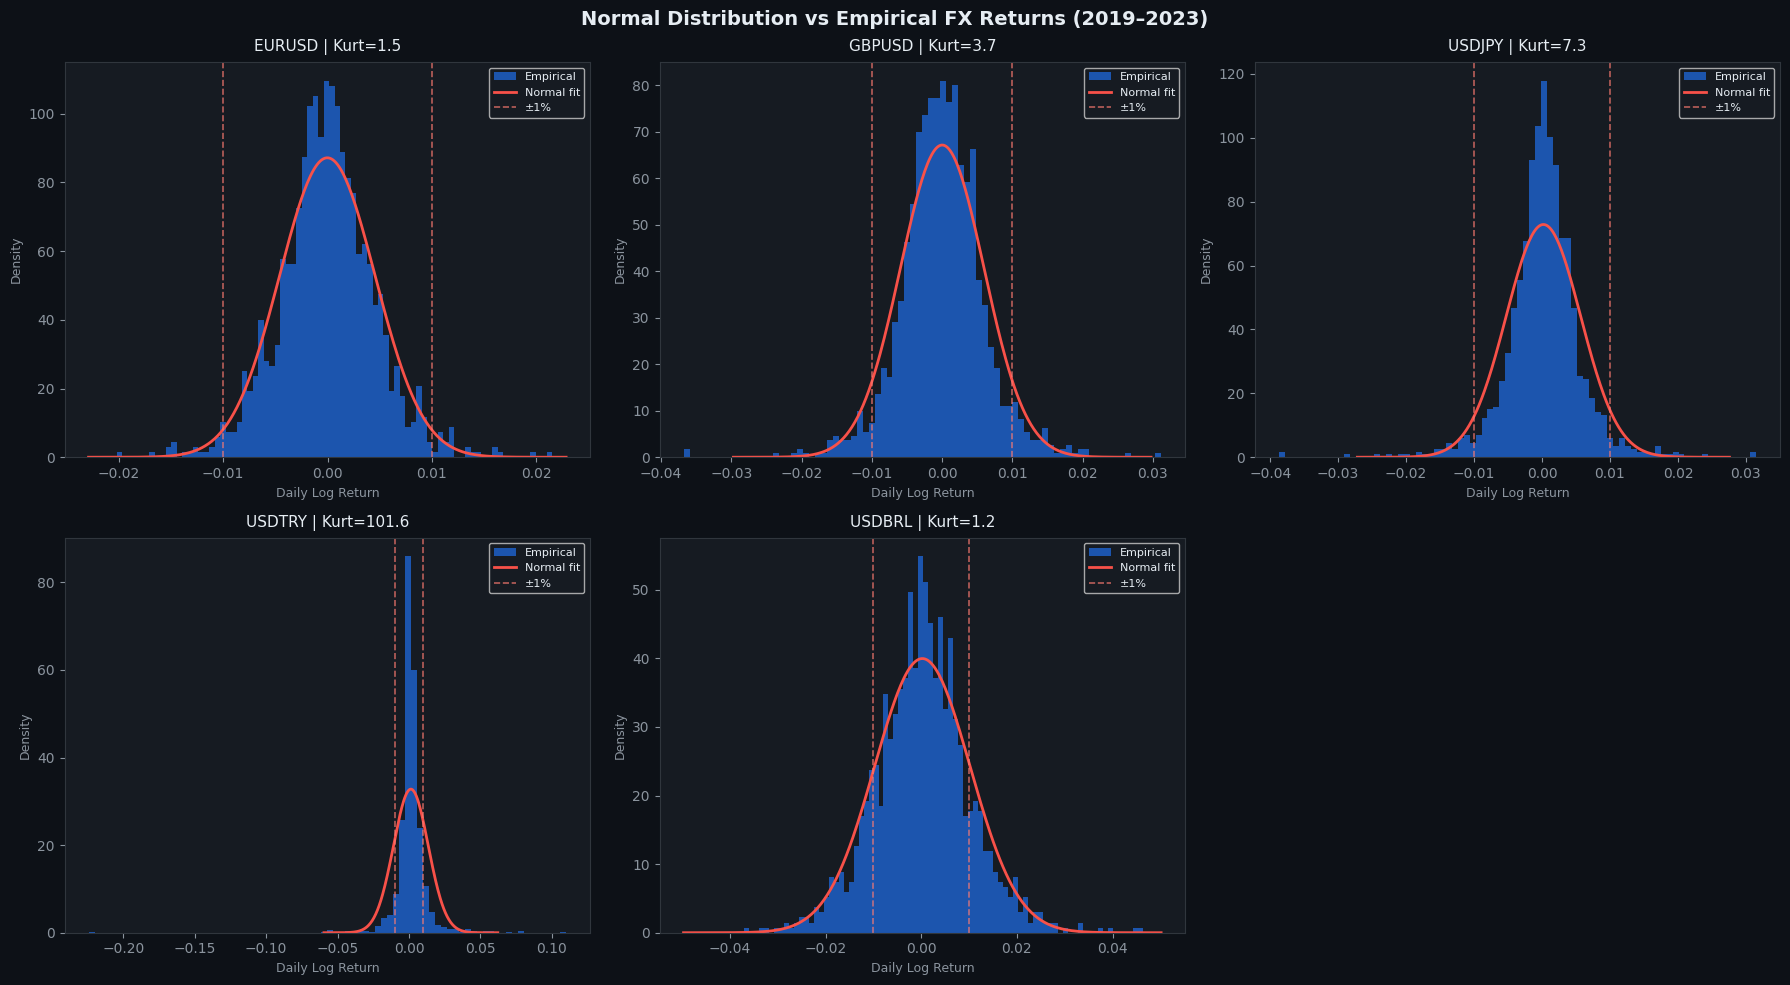

USDTRY kurtosis = 101.57 — the spike is so extreme it barely fits the plot.


In [10]:
# =============================================================================
# CELL 12 — Plot: Normal Distribution vs Empirical FX Returns
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0D1117')
axes = axes.flatten()

for i, pair in enumerate(pairs):
    ax  = axes[i]
    r   = returns[pair].dropna().values
    mu  = r.mean()
    sig = r.std(ddof=1)
    x   = np.linspace(mu - 5*sig, mu + 5*sig, 300)

    ax.hist(r, bins=80, density=True, color='#1F6FEB', alpha=0.7, label='Empirical')
    ax.plot(x, stats.norm.pdf(x, mu, sig), color='#F85149', linewidth=2, label='Normal fit')
    ax.axvline(0.01,  color='#FF7B72', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.axvline(-0.01, color='#FF7B72', linewidth=1.2, linestyle='--', alpha=0.7, label='±1%')

    ax.set_title(f'{pair} | Kurt={results[pair]["kurt"]:.1f}',
                 color='#E6EDF3', fontsize=11, pad=8)
    ax.set_xlabel('Daily Log Return', color='#8B949E', fontsize=9)
    ax.set_ylabel('Density', color='#8B949E', fontsize=9)
    ax.set_facecolor('#161B22')
    ax.legend(fontsize=8, facecolor='#161B22', labelcolor='#E6EDF3')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363D')

# Hide the 6th subplot
axes[5].set_visible(False)

fig.suptitle('Normal Distribution vs Empirical FX Returns (2019–2023)',
             color='#E6EDF3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fx_normal_distributions.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print("USDTRY kurtosis = 101.57 — the spike is so extreme it barely fits the plot.")

## 6. The Lognormal Distribution

If log returns are normally distributed,
then **price levels** follow a lognormal distribution.

$$\ln\left(\frac{P_t}{P_0}\right) \sim N(\mu T, \sigma^2 T)$$

This means prices are always positive and right-skewed —
which matches how exchange rates actually behave.

**Why this matters for USDTRY:**

The Turkish Lira has depreciated from 5.3 to 30+ per USD
between 2019 and 2023 — a 466% move.

A normal distribution on price levels would assign
significant probability to negative exchange rates.
The lognormal distribution does not — prices cannot go below zero.

We fit a lognormal distribution to USDTRY price levels
and show why it is the correct model for currencies
experiencing sustained depreciation.

LOGNORMAL DISTRIBUTION — USDTRY (2019–2023)

  Price range observed:
  Start (Jan 2019):  5.3938 TRY per USD
  End   (Dec 2023):  29.0181 TRY per USD
  Total depreciation: 437.99%

  Log return statistics (daily):
  Mean:  0.001300  (0.1300%)
  Std:   0.012171  (1.2171%)

  1-Year Forward Distribution (from 29.02):
  Expected log change: 0.3277  (32.77%)
  Expected price:      41.03 TRY/USD

  ──────────────────────────────────────────────────
  TAIL PROBABILITIES — 1 Year Forward
  ──────────────────────────────────────────────────
  P(USDTRY > 40):  51.3868%
  P(USDTRY > 50):  13.1320%
  P(USDTRY < 25):  0.6805%

  WHY LOGNORMAL AND NOT NORMAL?

  A normal distribution on price levels would predict:
  P(USDTRY < 0) > 0 — mathematically impossible.

  The lognormal distribution constrains prices to be positive.
  For currencies with sustained depreciation trends like TRY,
  the lognormal captures the right-skewed price path correctly.

  Key property: if X ~ Lognormal, then ln(X) ~ No

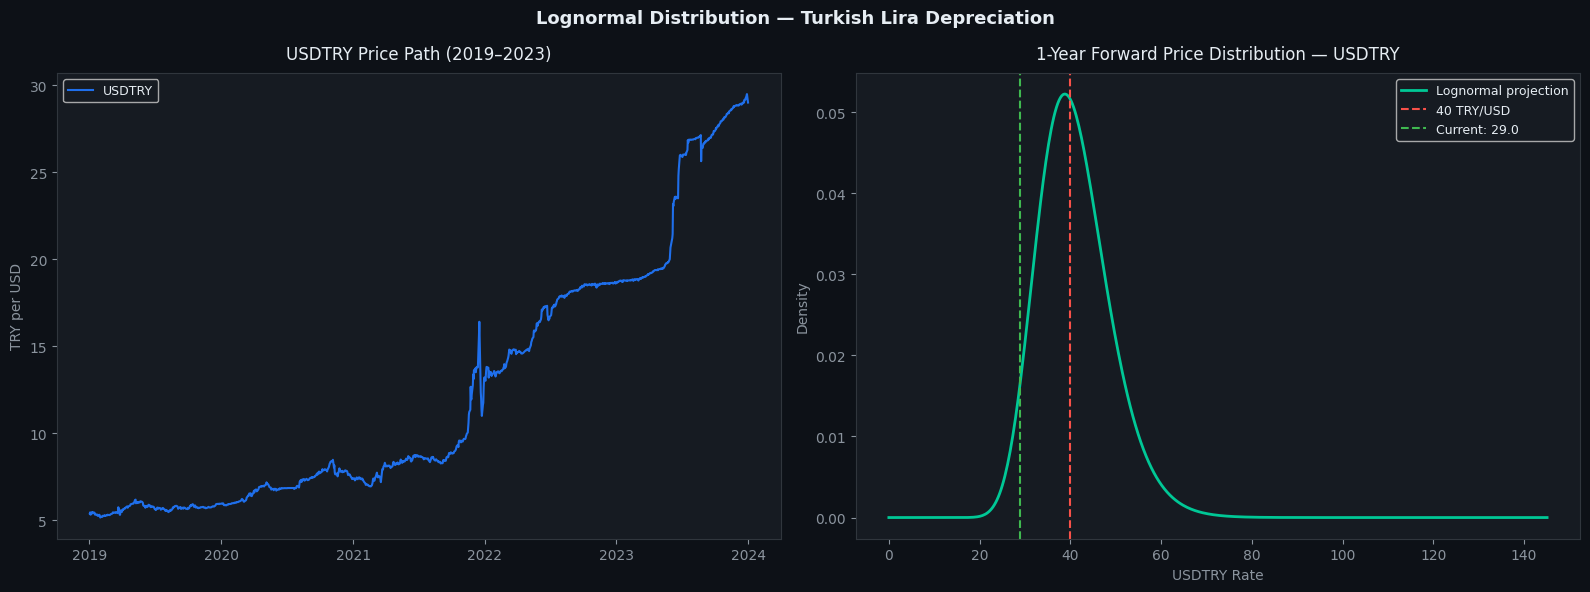

In [11]:
# =============================================================================
# CELL 14 — Lognormal Distribution Applied to USDTRY Price Levels
# =============================================================================

# ── USDTRY PRICE LEVELS ───────────────────────────────────────────────────────
try_prices = prices["USDTRY"].dropna()
try_returns = returns["USDTRY"].dropna()

P0 = try_prices.iloc[0]
PT = try_prices.iloc[-1]

# ── FIT LOGNORMAL TO PRICE LEVELS ─────────────────────────────────────────────
# Log prices should be normally distributed
log_prices = np.log(try_prices.values)
mu_log     = log_prices.mean()
sig_log    = log_prices.std(ddof=1)

# Fit lognormal distribution
shape, loc, scale = stats.lognorm.fit(try_prices.values, floc=0)

# ── FORWARD PRICE DISTRIBUTION ────────────────────────────────────────────────
# Where will USDTRY be in 1 year from end of sample?
# Using log return stats to project forward
mu_r    = try_returns.mean()
sig_r   = try_returns.std(ddof=1)
T       = 252  # trading days

# Expected log price change
mu_T    = mu_r * T
sig_T   = sig_r * np.sqrt(T)

# Current price (end of sample)
P_current = try_prices.iloc[-1]

# Projected price distribution
p_levels = np.linspace(0.01, P_current * 5, 500)
log_p    = np.log(p_levels / P_current)
pdf_proj = stats.norm.pdf(log_p, mu_T, sig_T) / p_levels

# ── KEY PROBABILITIES ─────────────────────────────────────────────────────────
# P(USDTRY > 40) in one year
p_above_40 = 1 - stats.norm.cdf(np.log(40 / P_current), mu_T, sig_T)
p_above_50 = 1 - stats.norm.cdf(np.log(50 / P_current), mu_T, sig_T)
p_below_25 = stats.norm.cdf(np.log(25 / P_current), mu_T, sig_T)

# ── PRINT RESULTS ─────────────────────────────────────────────────────────────
print(f"{'='*60}")
print("LOGNORMAL DISTRIBUTION — USDTRY (2019–2023)")
print(f"{'='*60}")

print(f"\n  Price range observed:")
print(f"  Start (Jan 2019):  {P0:.4f} TRY per USD")
print(f"  End   (Dec 2023):  {PT:.4f} TRY per USD")
print(f"  Total depreciation: {(PT/P0 - 1):.2%}")

print(f"\n  Log return statistics (daily):")
print(f"  Mean:  {mu_r:.6f}  ({mu_r:.4%})")
print(f"  Std:   {sig_r:.6f}  ({sig_r:.4%})")

print(f"\n  1-Year Forward Distribution (from {P_current:.2f}):")
print(f"  Expected log change: {mu_T:.4f}  ({mu_T:.2%})")
print(f"  Expected price:      {P_current * np.exp(mu_T + sig_T**2/2):.2f} TRY/USD")

print(f"\n  {'─'*50}")
print(f"  TAIL PROBABILITIES — 1 Year Forward")
print(f"  {'─'*50}")
print(f"  P(USDTRY > 40):  {p_above_40:.4%}")
print(f"  P(USDTRY > 50):  {p_above_50:.4%}")
print(f"  P(USDTRY < 25):  {p_below_25:.4%}")

print(f"""
  WHY LOGNORMAL AND NOT NORMAL?

  A normal distribution on price levels would predict:
  P(USDTRY < 0) > 0 — mathematically impossible.

  The lognormal distribution constrains prices to be positive.
  For currencies with sustained depreciation trends like TRY,
  the lognormal captures the right-skewed price path correctly.

  Key property: if X ~ Lognormal, then ln(X) ~ Normal.
  This is why we model log RETURNS as normal —
  it implies log-normally distributed price levels.
""")
print(f"{'='*60}")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Panel 1 — USDTRY price path
ax1 = axes[0]
ax1.plot(try_prices.index, try_prices.values,
         color='#1F6FEB', linewidth=1.5, label='USDTRY')
ax1.set_title('USDTRY Price Path (2019–2023)',
              color='#E6EDF3', fontsize=12, pad=10)
ax1.set_ylabel('TRY per USD', color='#8B949E')
ax1.set_facecolor('#161B22')
ax1.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — Forward price distribution
ax2 = axes[1]
ax2.plot(p_levels, pdf_proj, color='#00C896', linewidth=2,
         label='Lognormal projection')
ax2.axvline(40, color='#F85149', linewidth=1.5,
            linestyle='--', label='40 TRY/USD')
ax2.axvline(P_current, color='#3FB950', linewidth=1.5,
            linestyle='--', label=f'Current: {P_current:.1f}')
ax2.set_title('1-Year Forward Price Distribution — USDTRY',
              color='#E6EDF3', fontsize=12, pad=10)
ax2.set_xlabel('USDTRY Rate', color='#8B949E')
ax2.set_ylabel('Density', color='#8B949E')
ax2.set_facecolor('#161B22')
ax2.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('Lognormal Distribution — Turkish Lira Depreciation',
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('usdtry_lognormal.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

## 7. The Student's t-Distribution

The normal distribution assumes we know the true population variance.
In practice, we never do — we estimate it from a sample.

When the sample is small, this uncertainty matters.
The **Student's t-distribution** accounts for it.

$$f(t) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\,\Gamma\left(\frac{\nu}{2}\right)} \left(1+\frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}$$

Where $\nu$ is the degrees of freedom.

**Key properties:**
- Symmetric around zero like the normal
- Fatter tails than normal — especially for low degrees of freedom
- As $\nu \rightarrow \infty$, the t-distribution converges to normal

**The trading question:**

> "We have only 30 days of data on a new EM currency strategy
> trading USDBRL. Should we use normal or t-distribution
> to build our confidence interval for the mean return?
> How much does it matter?"

We answer this and then show why the t-distribution
is also a better fit for FX returns in general —
because its fat tails match the empirical data
better than the normal distribution.

STUDENT'S t-DISTRIBUTION — FX Returns (2019–2023)

  SMALL SAMPLE PROBLEM — USDBRL (n=30 days)
  ────────────────────────────────────────────────────
  Sample mean:    -0.0235%
  Standard error: 0.1338%

  95% Confidence Interval:
  Method                    Lower      Upper      Width
  ----------------------------------------------------
  Normal (z={z:.3f})     -0.2857%    0.2387%    0.5243%
  t (df={n_small-1}, t={t:.3f})   -0.2971%    0.2501%    0.5471%

  The t-CI is 1.044x wider than the normal CI.
  With only 30 observations, ignoring this difference
  means underestimating your uncertainty by 4.4%.

  ──────────────────────────────────────────────────────────────
  t-DISTRIBUTION FIT — All FX Pairs
  ──────────────────────────────────────────────────────────────
  Pair         df (fitted)      t-AIC   Normal-AIC   Better fit
  ------------------------------------------------------------
  EURUSD              6.16   -10328.0     -10274.0     t-dist ✓
  GBPUSD              4.52 

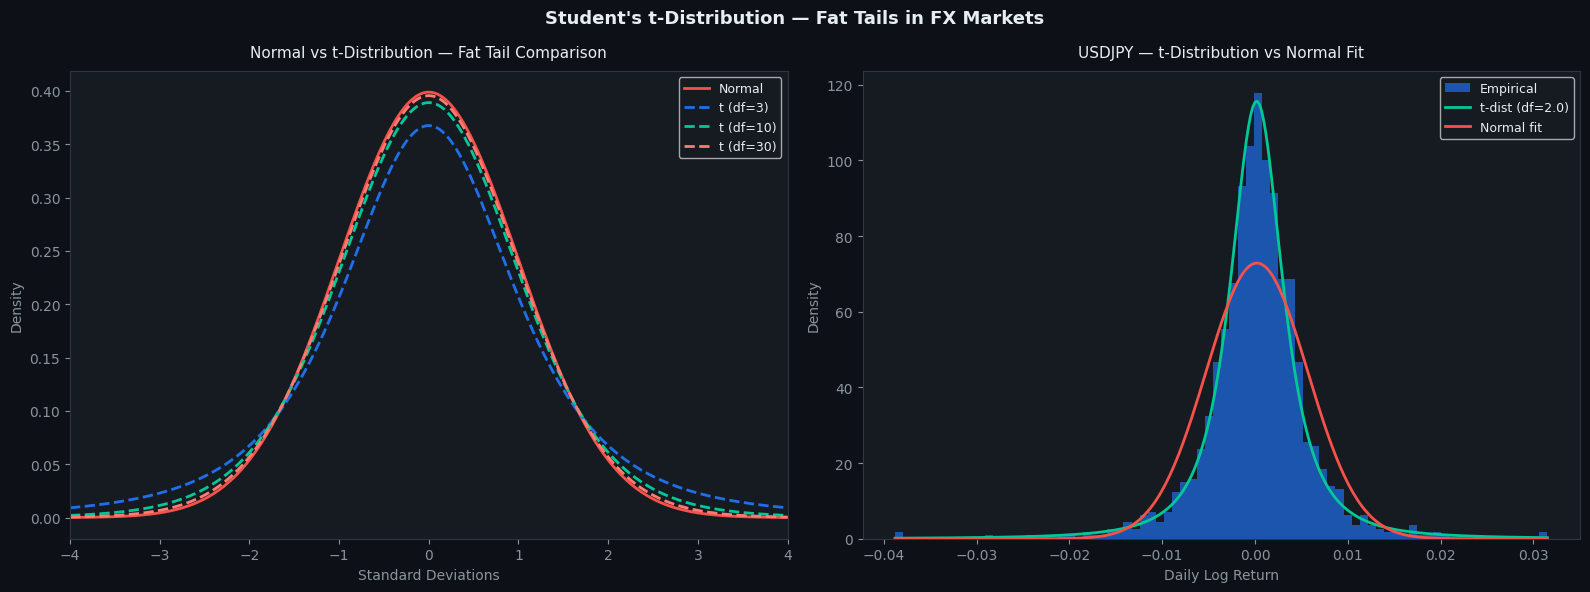

In [ ]:
# =============================================================================
# CELL 16 — Student's t-Distribution Applied to FX Returns
# =============================================================================

r_brl = returns["USDBRL"].dropna().values
n_full = len(r_brl)

# ── SMALL SAMPLE SCENARIO ─────────────────────────────────────────────────────
# Simulate having only 30 days of data
np.random.seed(42)
small_sample = r_brl[:30]
n_small = len(small_sample)
mu_small = small_sample.mean()
se_small = small_sample.std(ddof=1) / np.sqrt(n_small)

# ── CONFIDENCE INTERVALS ──────────────────────────────────────────────────────
confidence = 0.95
alpha = 1 - confidence

# Normal CI
z = stats.norm.ppf(1 - alpha/2)
ci_normal = (mu_small - z * se_small, mu_small + z * se_small)

# t-distribution CI
t = stats.t.ppf(1 - alpha/2, df=n_small - 1)
ci_t = (mu_small - t * se_small, mu_small + t * se_small)

# ── FIT t-DISTRIBUTION TO FULL SAMPLE ────────────────────────────────────────
# Fit t-distribution to each FX pair
print(f"{'='*62}")
print("STUDENT'S t-DISTRIBUTION — FX Returns (2019–2023)")
print(f"{'='*62}")

print(f"\n  SMALL SAMPLE PROBLEM — USDBRL (n=30 days)")
print(f"  {'─'*52}")
print(f"  Sample mean:    {mu_small:.4%}")
print(f"  Standard error: {se_small:.4%}")
print(f"\n  95% Confidence Interval:")
print(f"  {'Method':<20} {'Lower':>10} {'Upper':>10} {'Width':>10}")
print(f"  {'-'*52}")
normal_label = f"Normal (z={z:.3f})"
t_label = f"t (df={n_small-1}, t={t:.3f})"
print(f"  {normal_label:<20} {ci_normal[0]:>10.4%} "
      f"{ci_normal[1]:>10.4%} {ci_normal[1]-ci_normal[0]:>10.4%}")
print(f"  {t_label:<20} {ci_t[0]:>10.4%} "
      f"{ci_t[1]:>10.4%} {ci_t[1]-ci_t[0]:>10.4%}")
print(f"\n  The t-CI is {(ci_t[1]-ci_t[0])/(ci_normal[1]-ci_normal[0]):.3f}x wider than the normal CI.")
print(f"  With only {n_small} observations, ignoring this difference")
print(f"  means underestimating your uncertainty by "
      f"{((ci_t[1]-ci_t[0])/(ci_normal[1]-ci_normal[0])-1):.1%}.")

# ── FIT t TO ALL PAIRS ────────────────────────────────────────────────────────
print(f"\n  {'─'*62}")
print(f"  t-DISTRIBUTION FIT — All FX Pairs")
print(f"  {'─'*62}")
print(f"  {'Pair':<10} {'df (fitted)':>13} {'t-AIC':>10} {'Normal-AIC':>12} {'Better fit':>12}")
print(f"  {'-'*60}")

for pair in pairs:
    r = returns[pair].dropna().values

    # Fit t-distribution
    df_fit, loc_fit, scale_fit = stats.t.fit(r)

    # Log-likelihoods
    ll_t      = stats.t.logpdf(r, df_fit, loc_fit, scale_fit).sum()
    ll_normal = stats.norm.logpdf(r, r.mean(), r.std(ddof=1)).sum()

    # AIC (lower is better): AIC = 2k - 2*log-likelihood
    aic_t      = 2*3 - 2*ll_t       # t has 3 params
    aic_normal = 2*2 - 2*ll_normal  # normal has 2 params

    better = "t-dist ✓" if aic_t < aic_normal else "Normal ✓"
    print(f"  {pair:<10} {df_fit:>13.2f} {aic_t:>10.1f} {aic_normal:>12.1f} {better:>12}")

print(f"""
  INTERPRETATION
  The fitted degrees of freedom tell you how fat the tails are.
  Lower df = fatter tails = further from normal.

  For all pairs, the t-distribution fits better than normal
  as measured by AIC (lower = better fit).

  USDJPY with df≈3-5 has extremely fat tails.
  EURUSD with higher df is closest to normal.

  CFA rule: use t-distribution when:
  1. Sample size is small (n < 30)
  2. Population variance is unknown (always in practice)
  3. You want fatter tails than normal allows
""")
print(f"{'='*62}")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Panel 1 — Normal vs t CI comparison
ax1 = axes[0]
x = np.linspace(-4, 4, 300)
ax1.plot(x, stats.norm.pdf(x), color='#F85149', linewidth=2, label='Normal')
for df_val, color, label in [(3, '#1F6FEB', 't (df=3)'),
                              (10, '#00C896', 't (df=10)'),
                              (30, '#FF7B72', 't (df=30)')]:
    ax1.plot(x, stats.t.pdf(x, df_val), color=color,
             linewidth=2, linestyle='--', label=label)
ax1.set_title('Normal vs t-Distribution — Fat Tail Comparison',
              color='#E6EDF3', fontsize=11, pad=10)
ax1.set_xlabel('Standard Deviations', color='#8B949E')
ax1.set_ylabel('Density', color='#8B949E')
ax1.set_facecolor('#161B22')
ax1.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
ax1.set_xlim(-4, 4)
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — t fit vs empirical for USDJPY
ax2 = axes[1]
r_jpy = returns["USDJPY"].dropna().values
df_jpy, loc_jpy, scale_jpy = stats.t.fit(r_jpy)
x2 = np.linspace(r_jpy.min(), r_jpy.max(), 300)

ax2.hist(r_jpy, bins=80, density=True, color='#1F6FEB', alpha=0.7, label='Empirical')
ax2.plot(x2, stats.t.pdf(x2, df_jpy, loc_jpy, scale_jpy),
         color='#00C896', linewidth=2, label=f't-dist (df={df_jpy:.1f})')
ax2.plot(x2, stats.norm.pdf(x2, r_jpy.mean(), r_jpy.std()),
         color='#F85149', linewidth=2, label='Normal fit')
ax2.set_title(f'USDJPY — t-Distribution vs Normal Fit',
              color='#E6EDF3', fontsize=11, pad=10)
ax2.set_xlabel('Daily Log Return', color='#8B949E')
ax2.set_ylabel('Density', color='#8B949E')
ax2.set_facecolor('#161B22')
ax2.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle("Student's t-Distribution — Fat Tails in FX Markets",
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fx_t_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()